In [1]:
import time
import json
import os
import sys
import math
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize

from pc import PS
from modules import ADC,DAC,CHIP,COMPENSATION_PARA
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import *

from network.layer import Layer

from scipy.stats import norm
from scipy.optimize import curve_fit
import random

In [15]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
# deviceType参数：0为ReRAM，1为ECRAM
# IsNew32参数：False为v1版本，True为v2版本
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_sample_times(adc_sample_times=16)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=1000,adc_last_gap=40)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("./compiler/code/")
chip.compensation.initop("../chip_data/chip6_/pcb_203/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 49254


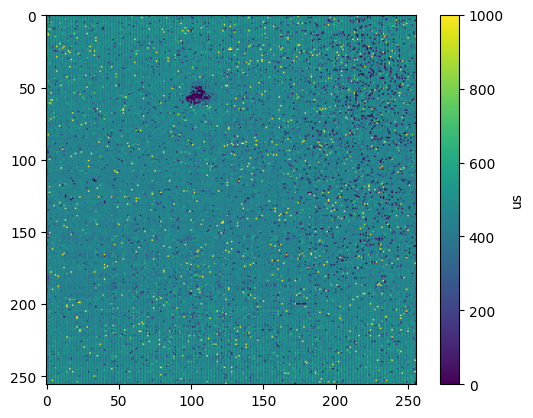

In [119]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=1,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

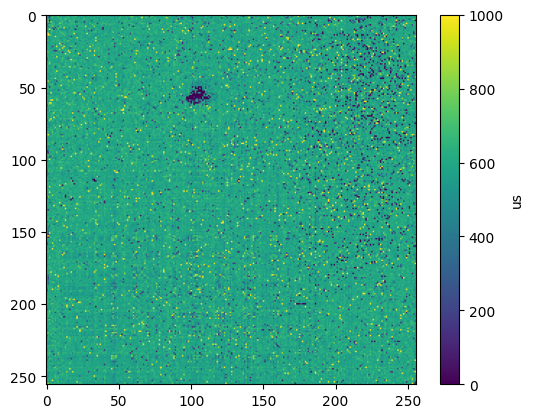

In [120]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [3]:
root_path = "../chip_data/chip6_/pcb_203/"

# 1. 准备数据

In [19]:
v,c_expected_from_row,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
c_expected_from_row = chip.compensation.compensation_point(r,from_row=True,return_type=0)

v,c_expected_from_col,r = chip.read4(crossbar=np.ones((256,256)),row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=False,split_type=0,row_type=0,col_type=0)
c_expected_from_col = chip.compensation.compensation_point(r,from_row=False,return_type=0)

## 1.0 计算R_out

In [ ]:
# 逐点读，split_type=0，使用crossbar参数
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [ ]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)

In [ ]:
# 注意！！！执行前一定要改名字
compensation = COMPENSATION_PARA()
filename = root_path + "col_r_out_base.npy"
point_read,sum_read = compensation.calculate_r_out_from_r_wire(chip=chip,num=30,from_row=True)
r_out_col = compensation.get_r_out(point_read=point_read,sum_read=sum_read,filename=filename,from_row=True)

In [ ]:
tmp = r_out_col.copy()
for i,v in enumerate(r_out_col):
    if v>25:
        tmp[i]=(tmp[i-1]+tmp[i+1])/2

filename = root_path + "col_r_out.npy"
np.save(filename,tmp)
plt.plot(tmp)
plt.xlabel("col")
plt.ylabel("Ω")
plt.show()

In [ ]:
filename = root_path + "row_r_out_base.npy"
point_read,sum_read = compensation.calculate_r_out_from_r_wire(chip=chip,num=30,from_row=False)
r_out_row = compensation.get_r_out(point_read=point_read,sum_read=sum_read,filename=filename,from_row=False)

In [ ]:
tmp = r_out_row.copy()
for i,v in enumerate(r_out_row):
    if v>25:
        tmp[i]=(tmp[i-1]+tmp[i+1])/2

filename = root_path + "row_r_out.npy"
np.save(filename,tmp)
plt.plot(tmp)
plt.show()
print(r_out_row)

In [ ]:
col_r_out = np.load(root_path + "col_r_out.npy")
plt.plot(col_r_out)
plt.show()

row_r_out = np.load(root_path + "row_r_out.npy")
plt.plot(row_r_out)
plt.show()

# 3. 计算补偿参数

### 3.1 单路

In [48]:
real_r = np.zeros((256,256))
expected_cond = np.zeros((256,256))

start_pos,end_pos = 0,100
row_index = [i for i in range(256)]
for i in range(start_pos,end_pos):
    col_index = [j for j in range(start_pos,i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=3,row_type=0,col_type=0)
    pos = np.ix_(row_index,col_index)
    expected_cond[i,:]=np.sum(c_expected_from_col[pos],axis=1).flatten()
    real_r[i,:]=r#/0.93801281
real_r = real_r[start_pos:end_pos,:]
expected_cond = expected_cond[start_pos:end_pos,:]

In [31]:
def compensation_para(input_indexs,offset,value,mult,r_wire,r_out,output_index,actual_output,expected_output,from_row,gain_r_mult):
    """
        为每一行,每一列,计算补偿的offset
        actual_output,expected_output格式,第一维度为第n次输入(开第n个索引),第二维度为输入的索引号
    """
    num = len(input_indexs)
    ans = np.zeros(num)

    tmp = []
    for k,i in enumerate(input_indexs):
        tmp.append(i)
        min_index,max_index = np.min(tmp),np.max(tmp)
        rw = (255-max_index)*r_wire if (from_row and output_index%2==0) or (not from_row and output_index%2==1) else (min_index)*r_wire

        # 第k次输入，输出索引为output_index,减去r_out,rw
        # offset是需要补偿的部分
        if gain_r_mult is not None:
            real_r = actual_output[k,output_index]*gain_r_mult*1e3 -r_out -rw + offset
        else:
            real_r = actual_output[k,output_index]*1e3 -r_out -rw + offset

        if value is not None:
            nums = len(tmp)
            real_r -= r_wire*((max_index-min_index+1)/nums)*(nums**value)
        ans[k]=1/real_r*1e6
    return ans/expected_output[:num,output_index]*mult

In [42]:
gain_r_mult_fit = np.zeros(256)
for col in range(0,256):
    print("col=",col)
    ans = []
    ans2 = []
    for i in range(50):
        num = random.randint(5, 10)
        start = random.randint(10, 200)
        v,c,r = chip.read4(crossbar=None,row_index=[i for i in range(start,start+num)],col_index=[col],read_voltage=0.1,tg=5,gain=1,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
        ans.append(c[col])
        v,c,r = chip.read4(crossbar=None,row_index=[i for i in range(start,start+num)],col_index=[col],read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=True,split_type=3,row_type=0,col_type=0)
        ans2.append(c[col])

    params, covariance = curve_fit(lambda x, mult: x * mult, np.array(ans2),np.array(ans), p0=[0.94],bounds=([0], [2]))
    gain_r_mult_fit[col] = params[0]
    print(params[0])

np.save(root_path + "row_gain_r_mult.npy",gain_r_mult_fit)

col= 0
0.9390791439033945
col= 1
0.9383777829997685
col= 2
0.9387015807888266
col= 3
0.9379269120452502
col= 4
0.9392179834844976
col= 5
0.938157046598444
col= 6
0.9393467229555017
col= 7
0.9381786377983519
col= 8
0.9390897279488265
col= 9
0.9381522914096173
col= 10
0.9391939790974655
col= 11
0.9380662857799753
col= 12
0.9391736773490362
col= 13
0.938003722027791
col= 14
0.938820164507044
col= 15
0.9378935168773266
col= 16
0.9380381629274405
col= 17
0.9364614423978705
col= 18
0.9375854011302123
col= 19
0.9369068075928143
col= 20
0.9383021857221262
col= 21
0.9365269235451061
col= 22
0.9377139827898433
col= 23
0.9364105392664264
col= 24
0.9378563257140353
col= 25
0.936385400823156
col= 26
0.9380681154145725
col= 27
0.9365118842026909
col= 28
0.9378273288904019
col= 29
0.9365338140602477
col= 30
0.9387148264014025
col= 31
0.9365520534604947
col= 32
0.9372015739363795
col= 33
0.9362758349175354
col= 34
0.9371305795397835
col= 35
0.9361798427926282
col= 36
0.9375893885670332
col= 37
0.93603

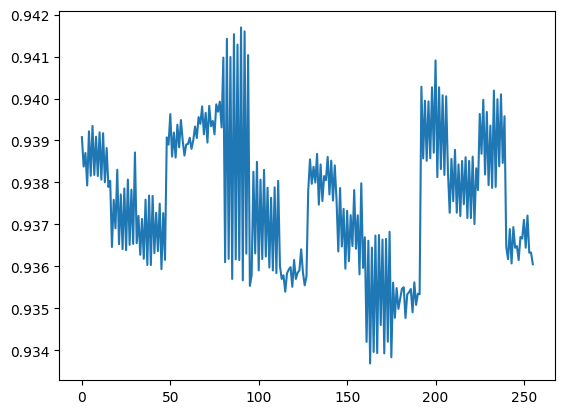

In [45]:
plt.plot(1/gain_r_mult_fit)
plt.show()

#### 3.1.1 拟合offset和gain_r_mult

In [ ]:
chip.compensation.initop(root_path)
from_row = False
r_wire = chip.compensation.r_wire
r_out = chip.compensation.col_r_out if from_row else chip.compensation.row_r_out
r_offset = 0

x = [i for i in range(start_pos,start_pos+30)]
y = np.ones(len(x))
offset_fit = np.zeros(256)
gain_r_mult_fit = np.zeros(256)
for output_index in range(256):
    fun_offset = lambda input_indexs,offset,gain_r_mult:compensation_para(input_indexs,offset,None,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row,gain_r_mult)
    params, covariance = curve_fit(fun_offset,x, y, p0=[1.0,1/0.93801281],bounds=([-5,1/0.945], [5,1/0.935]))
    offset_fit[output_index] = params[0]
    gain_r_mult_fit[output_index] = params[1]

np.save(root_path + "row_offset.npy",offset_fit)
# np.save(root_path + "row_gain_r_mult.npy",gain_r_mult_fit)

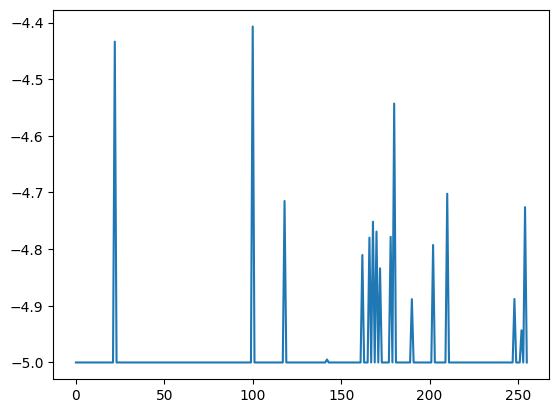

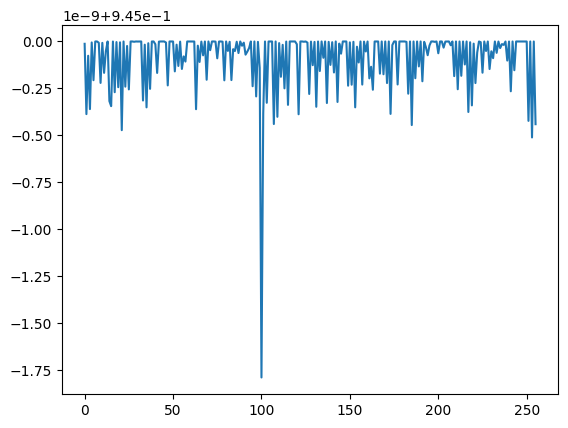

In [74]:
plt.plot(offset_fit)
plt.show()
plt.plot(1/gain_r_mult_fit)
plt.show()

#### 3.1.2 仅仅拟合offset

In [49]:
chip.compensation.initop(root_path)
from_row = False
r_wire = chip.compensation.r_wire
r_out = chip.compensation.col_r_out if from_row else chip.compensation.row_r_out
r_offset = 0
gain_r_mult_fit =1/np.load(root_path + "row_gain_r_mult.npy")

x = [i for i in range(start_pos,start_pos+30)]
y = np.ones(len(x))
offset_fit = np.zeros(256)
for output_index in range(256):
    fun_offset = lambda input_indexs,offset:compensation_para(input_indexs,offset,None,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row,gain_r_mult_fit[output_index])
    # gain_r_mult_fit[output_index]
    # fun_value = lambda input_indexs,value:compensation_offset(input_indexs,r_offset[output_index],value,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)
    # fun_value_mult = lambda input_indexs,value,mult:compensation_offset(input_indexs,r_offset[output_index],value,mult,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)

    params, covariance = curve_fit(fun_offset,x, y, p0=[1.0],bounds=([-30], [30]))
    offset_fit[output_index] = params[0]

np.save(root_path + "row_offset.npy",offset_fit)

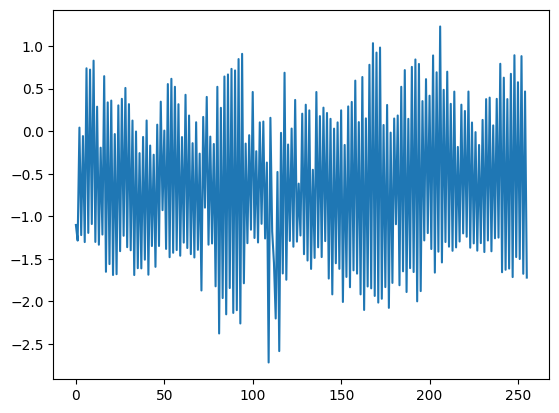

In [50]:
plt.plot(offset_fit)
plt.show()

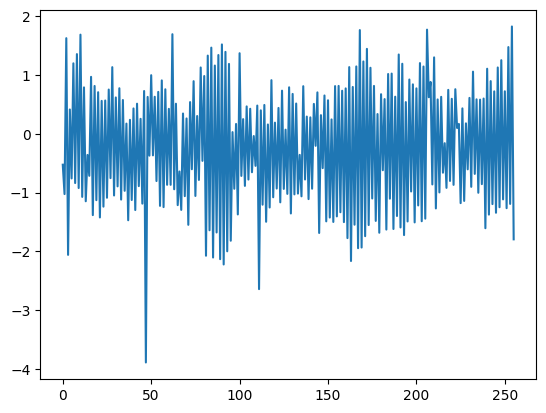

In [130]:
plt.plot(offset_fit)
plt.show()

#### 3.1.3 拟合value和mult

In [51]:
chip.compensation.initop(root_path)
from_row = False
r_wire = chip.compensation.r_wire
r_out = chip.compensation.col_r_out if from_row else chip.compensation.row_r_out
r_offset = np.load(root_path + "row_offset.npy")
gain_r_mult_fit =1/np.load(root_path + "row_gain_r_mult.npy")
x = [i for i in range(start_pos,end_pos)]
y = np.ones(len(x))
value_fit = np.zeros(256)
mult_fit = np.zeros(256)
for output_index in range(256):
    # fun_offset = lambda input_indexs,offset:compensation_offset(input_indexs,offset,None,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)
    # fun_value = lambda input_indexs,value:compensation_para(input_indexs,r_offset[output_index],value,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)
    fun_value_mult = lambda input_indexs,value,mult:compensation_para(input_indexs,r_offset[output_index],value,mult,r_wire,r_out[output_index],
                                                                      output_index,real_r,expected_cond,from_row,gain_r_mult_fit[output_index])


    params, covariance = curve_fit(fun_value_mult,x, y, p0=[0.5,1],bounds=([0,0.9], [1,1.1]))
    value_fit[output_index] = params[0]
    mult_fit[output_index] = params[1]
np.save(root_path + "row_value.npy",value_fit)
np.save(root_path + "row_mult1.npy",mult_fit)

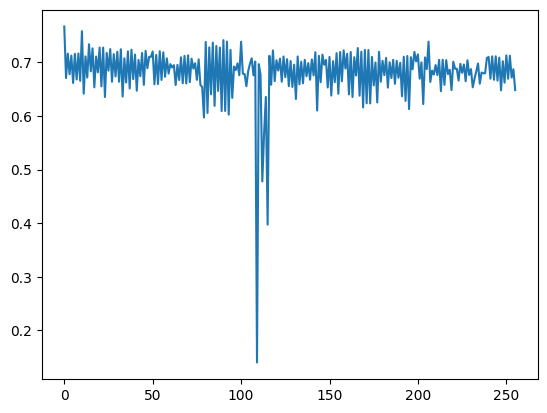

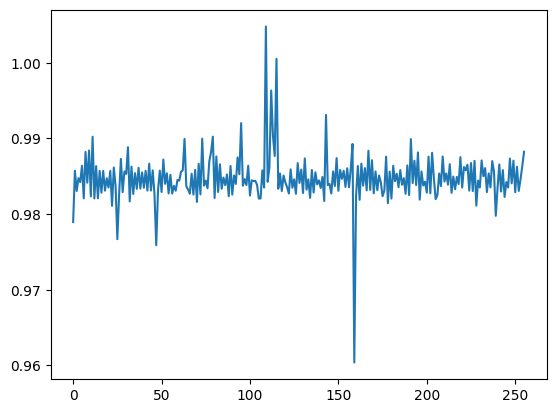

In [52]:
# np.save(root_path + "row_value.npy",value_fit)
plt.plot(value_fit)
plt.show()

plt.plot(mult_fit)
plt.show()

#### 1.3.4 仅仅拟合value

In [ ]:
chip.compensation.initop(root_path)
from_row = False
r_wire = chip.compensation.r_wire
r_out = chip.compensation.col_r_out if from_row else chip.compensation.row_r_out
r_offset = np.load(root_path + "row_offset.npy")

x = [i for i in range(start_pos,end_pos)]
y = np.ones(len(x))
value_fit = np.zeros(256)
for output_index in range(256):
    # fun_offset = lambda input_indexs,offset:compensation_offset(input_indexs,offset,None,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)
    fun_value = lambda input_indexs,value:compensation_para(input_indexs,r_offset[output_index],value,1,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)
    # fun_value_mult = lambda input_indexs,value,mult:compensation_para(input_indexs,r_offset[output_index],value,mult,r_wire,r_out[output_index],output_index,real_r,expected_cond,from_row = from_row)


    params, covariance = curve_fit(fun_value,x, y, p0=[0.5],bounds=([0], [1]))
    value_fit[output_index] = params[0]
np.save(root_path + "row_value.npy",value_fit)

In [ ]:
mult = np.ones(256)

In [ ]:
def compensation_value_from_col(x,mult,row):
    """
        计算补偿
    """
    rows = len(x)
    return real_cond[:rows,row]/expected_cond[:rows,row]*mult

cnt = end_pos

for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_value_from_col(x,value,i),[i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [1]))
    mult[i] = params[0]

In [53]:
chip.compensation.initop(root_path)
# chip.compensation.row_offset=0
# chip.compensation.row_value=None
# chip.compensation.row_r_out=0
# chip.compensation.row_gain_r_mult = 1
# self.row_gain_r_mult
real_cond = np.zeros((256,256))
row_index = [i for i in range(256)]
for i in range(start_pos,end_pos):
    col_index = [j for j in range(start_pos,i+1)]
    cond = chip.compensation.compensation_forward(col_index,real_r[i-start_pos,:],from_row=False,return_type=0)
    real_cond[i,:] = cond[row_index]
real_cond = real_cond[start_pos:end_pos,:]

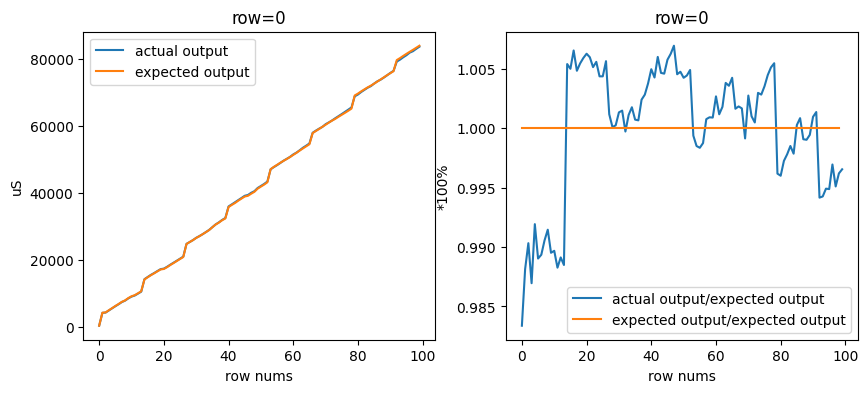

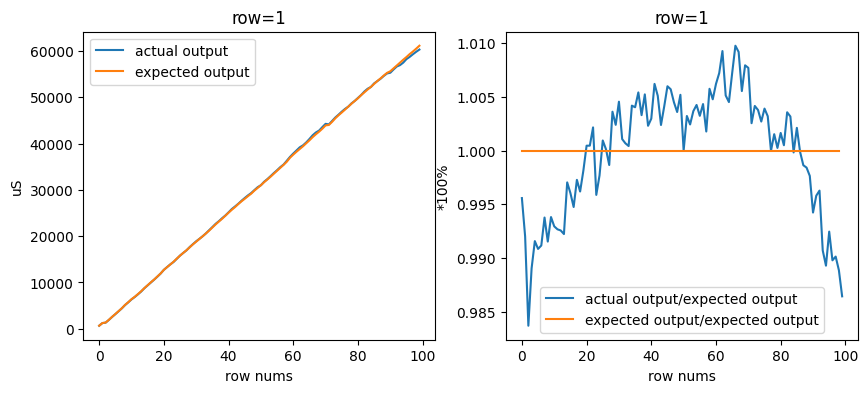

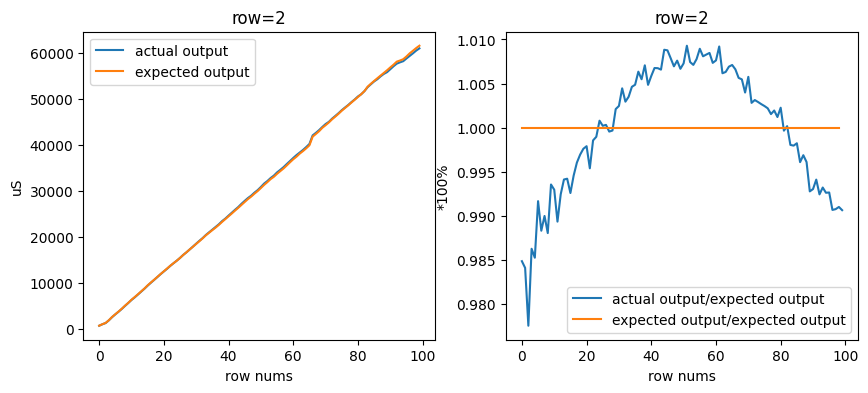

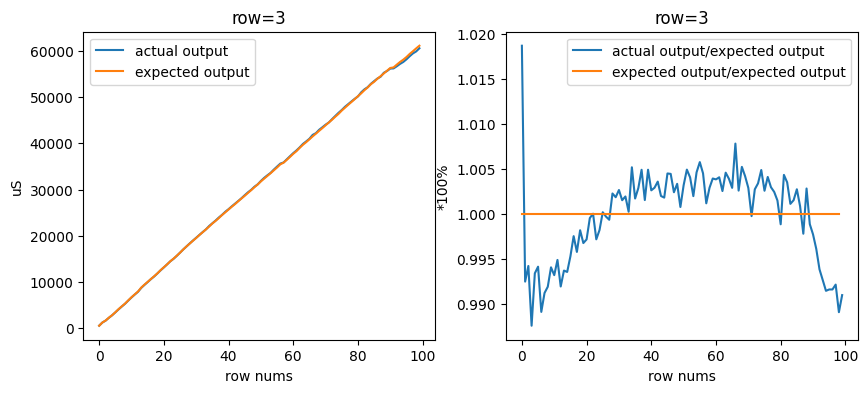

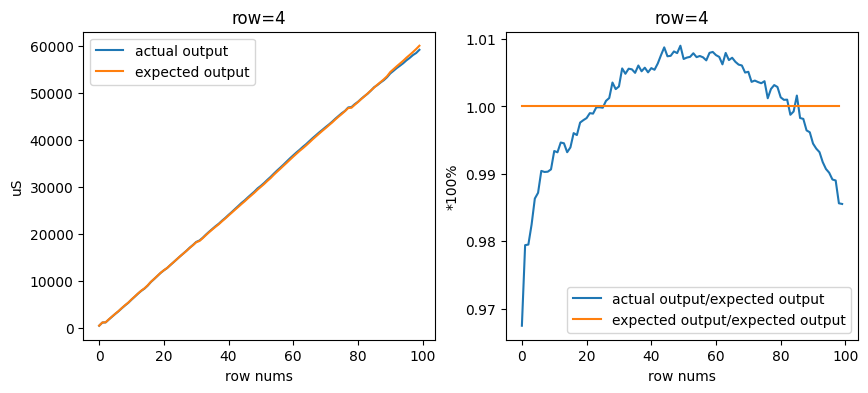

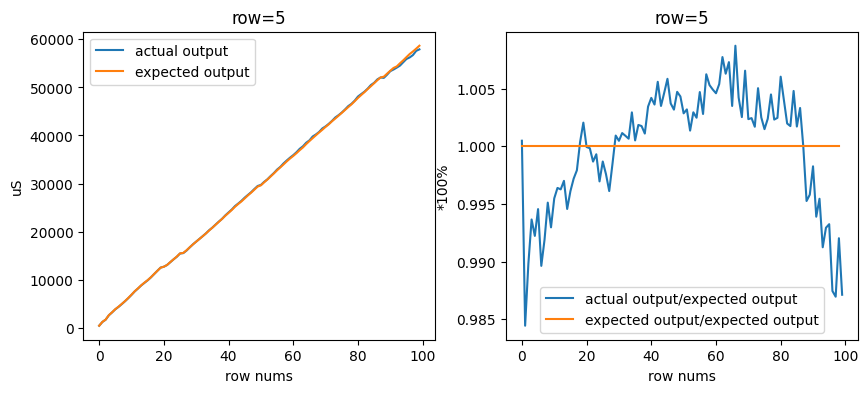

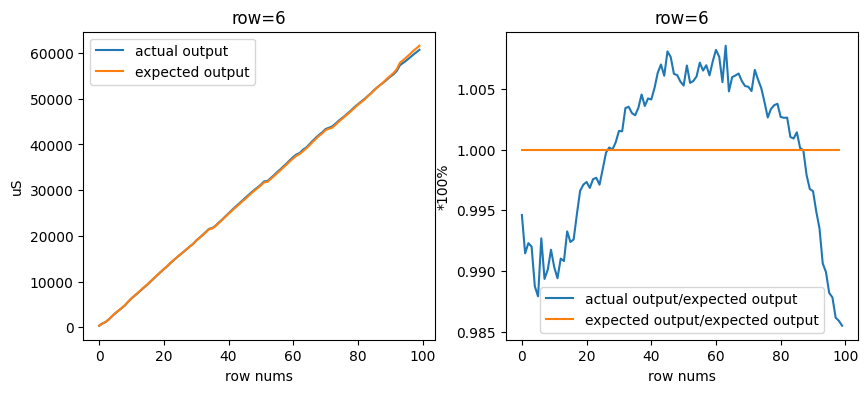

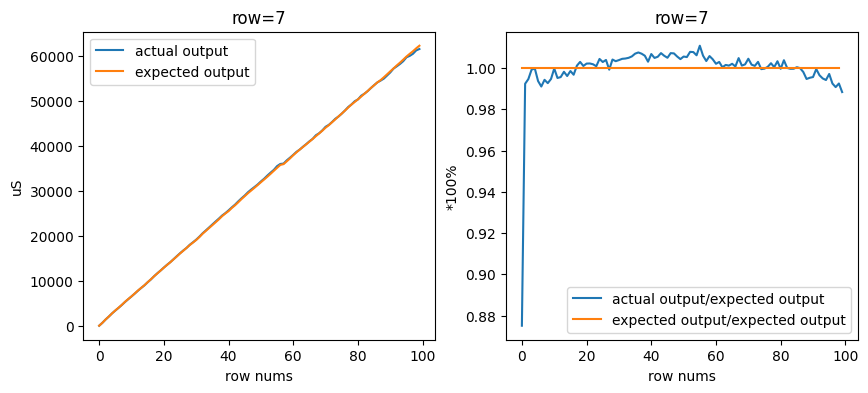

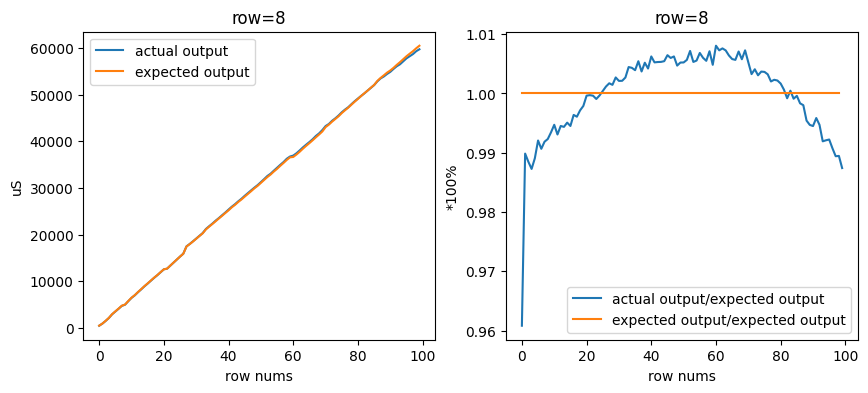

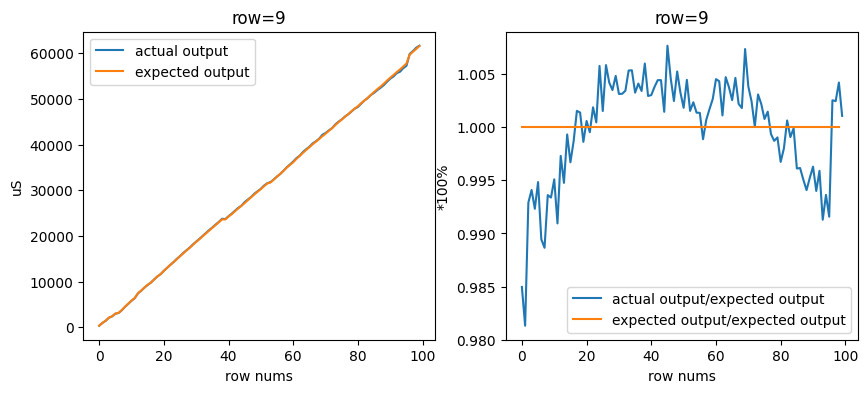

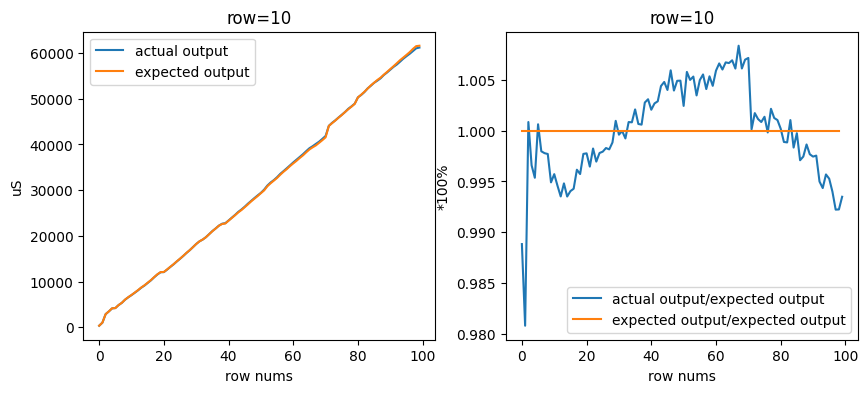

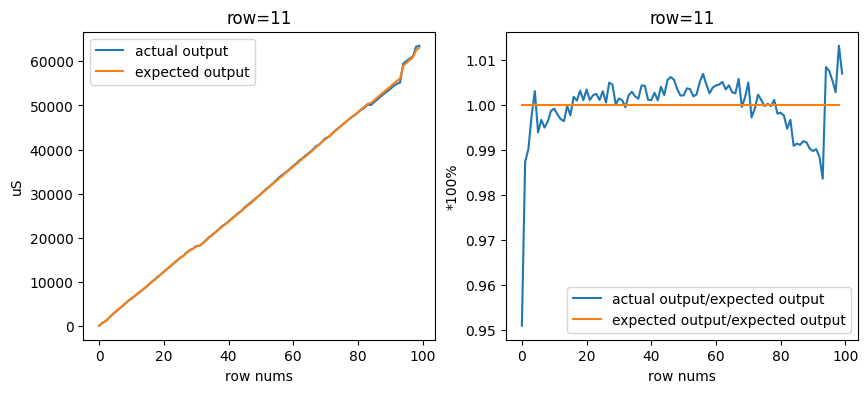

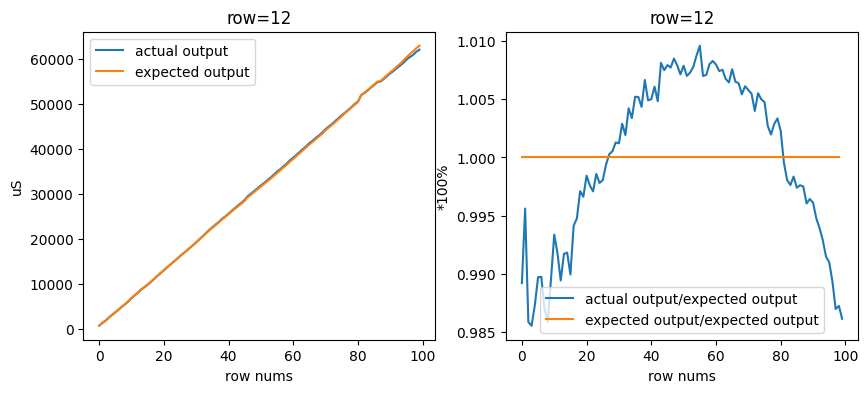

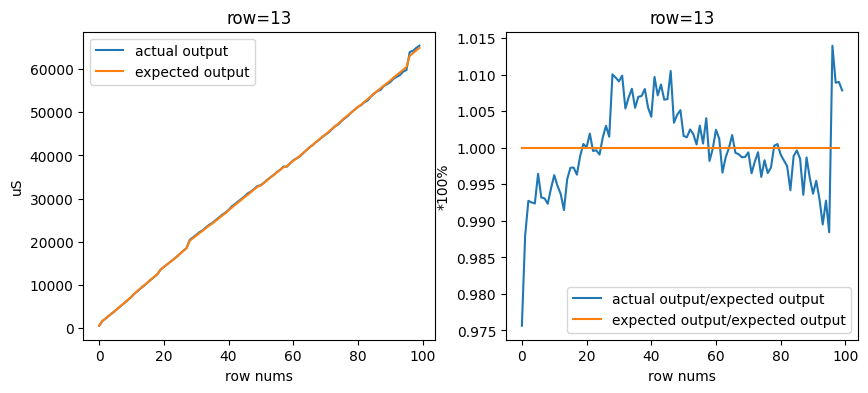

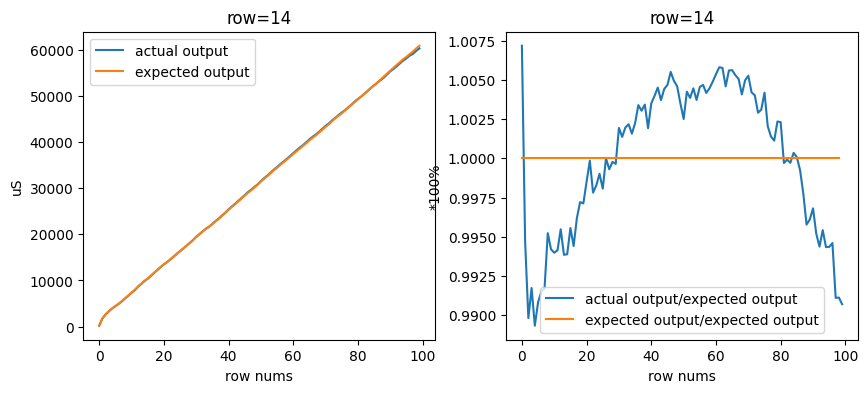

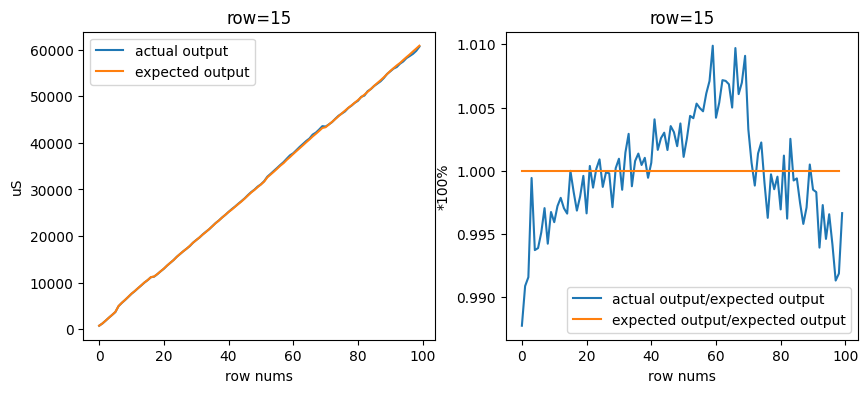

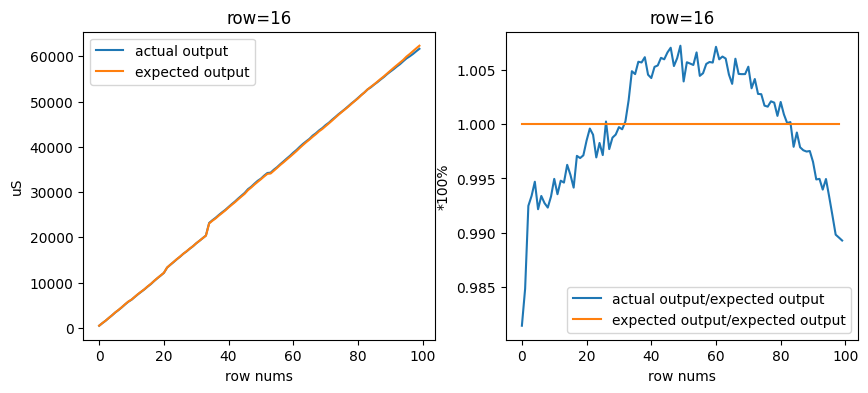

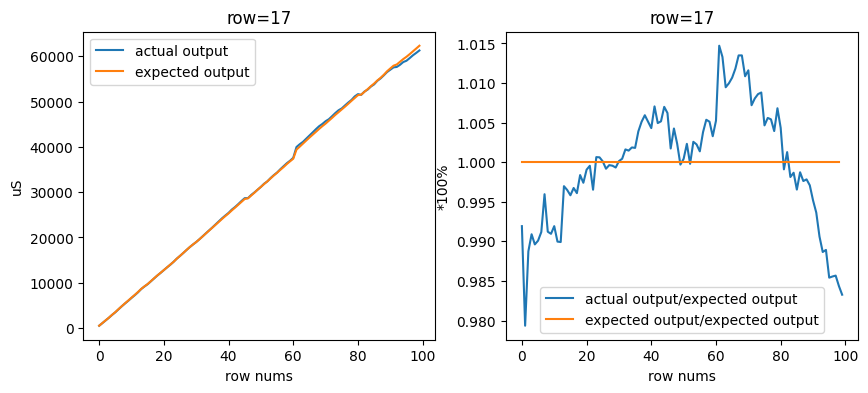

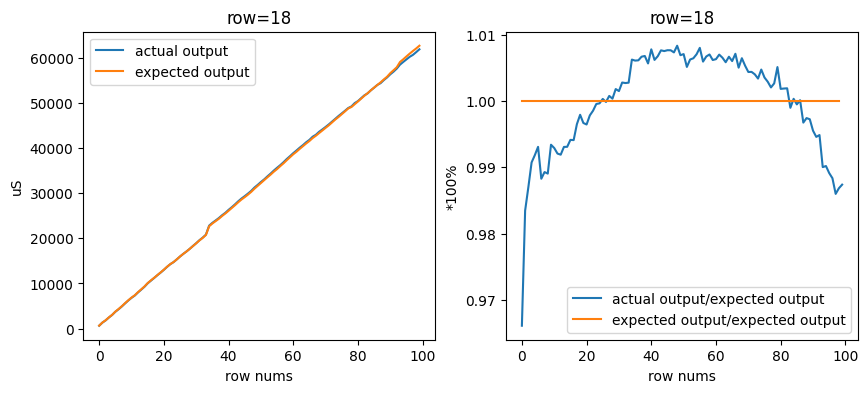

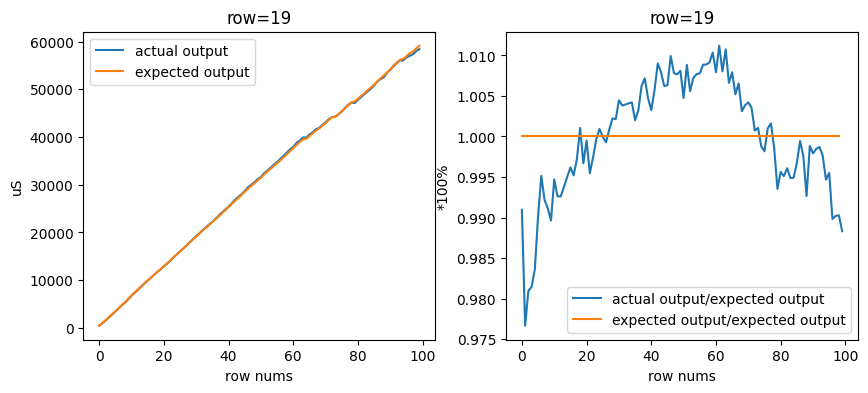

In [54]:
startpos,endpos = 0,100
for num in range(20):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond[startpos:endpos,num].flatten(),label = "actual output")
    plt.plot(expected_cond[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond[startpos:endpos,num].flatten()/expected_cond[startpos:endpos,num].flatten(),label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

### 3.2 32路并行读

In [55]:
chip.compensation.initop(root_path)
real_r = np.zeros((256,256))
expected_cond = np.zeros((256,256))
real_cond = np.zeros((256,256))
start_pos,end_pos = 0,100
row_index = [i for i in range(256)]


chip.compensation.initop(root_path)
# chip.compensation.row_offset=0
# chip.compensation.row_value=None
# chip.compensation.row_r_out=0
# chip.compensation.row_gain_r_mult = 1/0.93901281
# self.row_gain_r_mult


for i in range(start_pos,end_pos):
    col_index = [j for j in range(start_pos,i+1)]

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(col_index,r,from_row=False,return_type=0)
    pos = np.ix_(row_index,col_index)
    expected_cond[i,:]=np.sum(c_expected_from_col[pos],axis=1).flatten()
    real_r[i,:]=r
    real_cond[i,:] = cond[row_index]
real_r = real_r[start_pos:end_pos,:]
expected_cond = expected_cond[start_pos:end_pos,:]

In [57]:
def compensation_value_from_col(x,mult,row):
    """
        计算补偿
    """
    rows = len(x)
    return real_cond[:rows,row]/expected_cond[:rows,row]*mult

cnt = end_pos
mult_fit = np.zeros(256)
for i in range(256):
    params, covariance = curve_fit(lambda x,mult:compensation_value_from_col(x,mult,i),
                                   [i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [2]))
    mult_fit[i] = params[0]

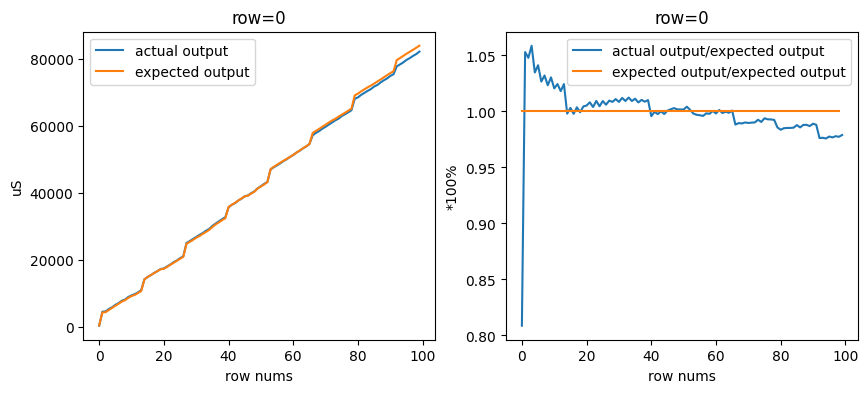

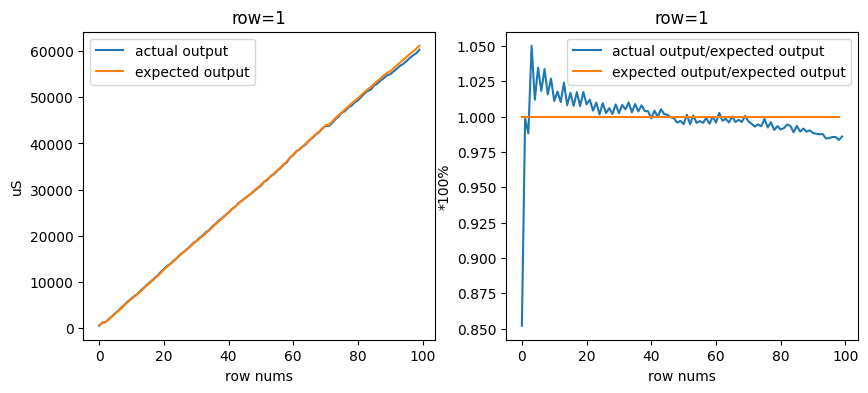

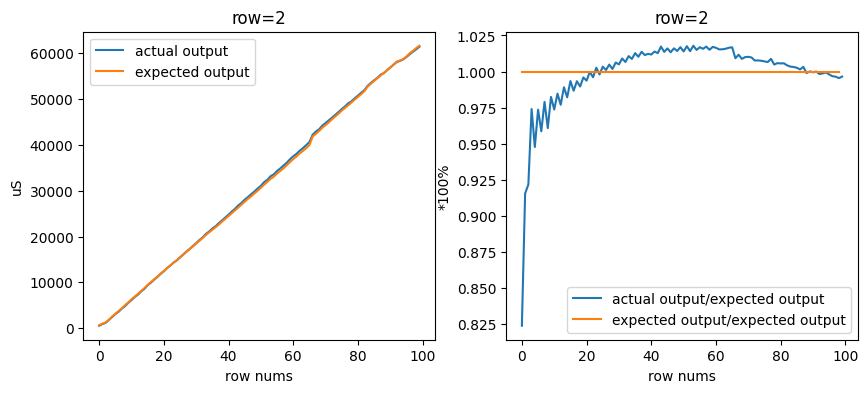

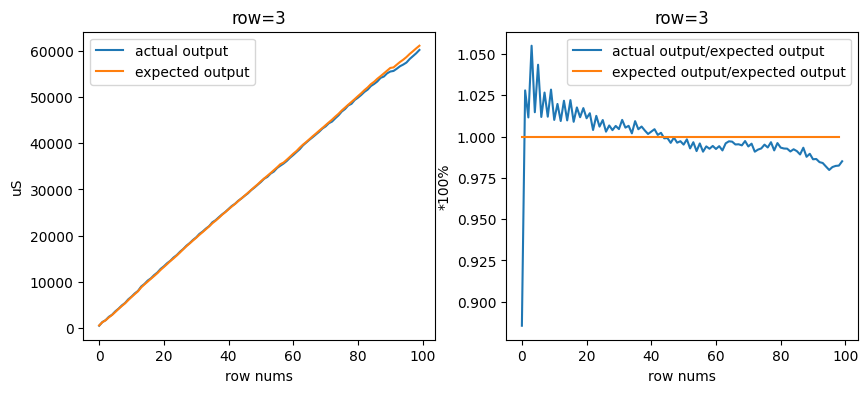

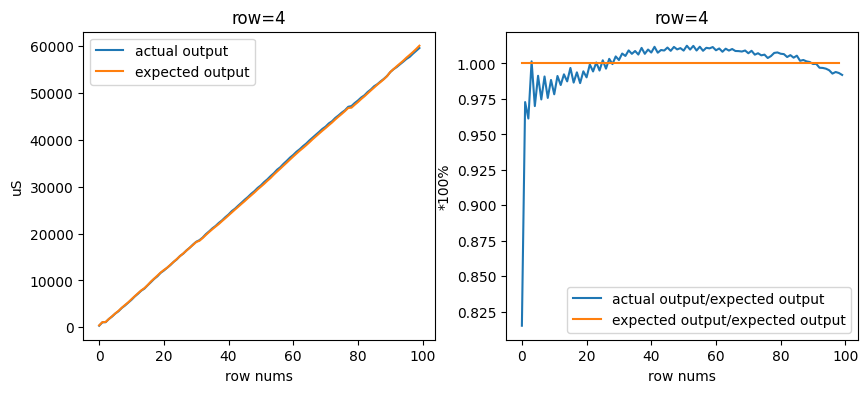

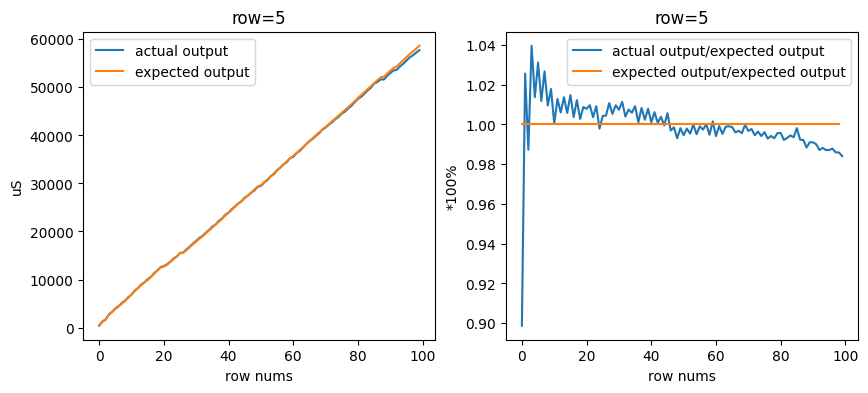

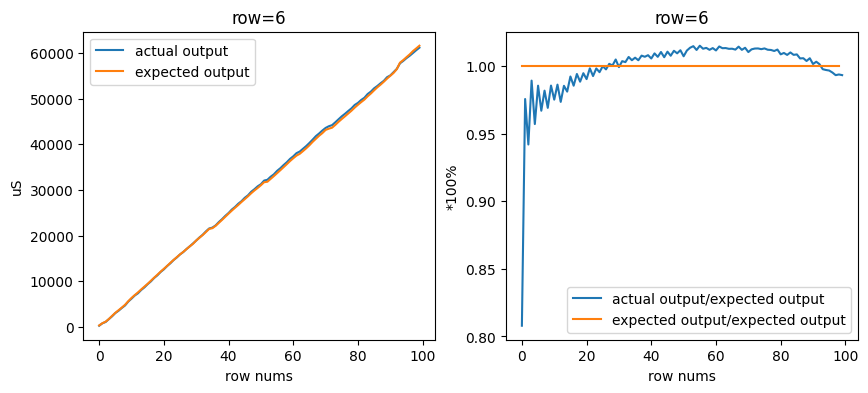

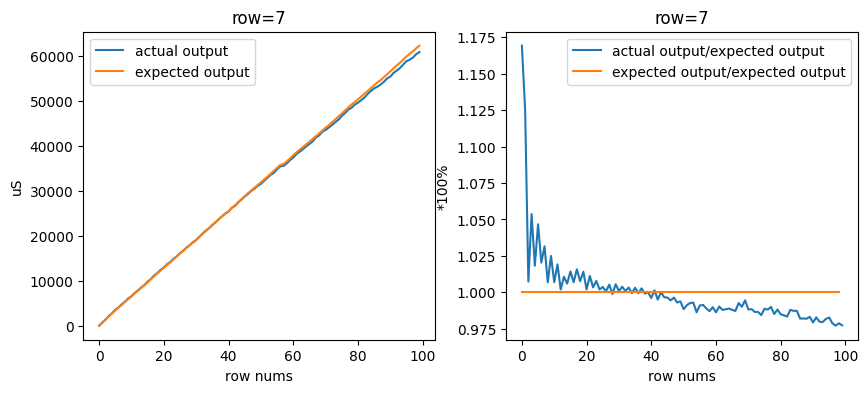

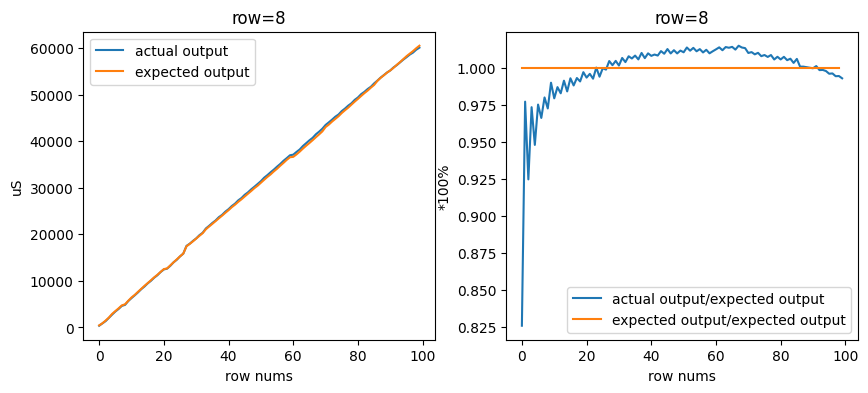

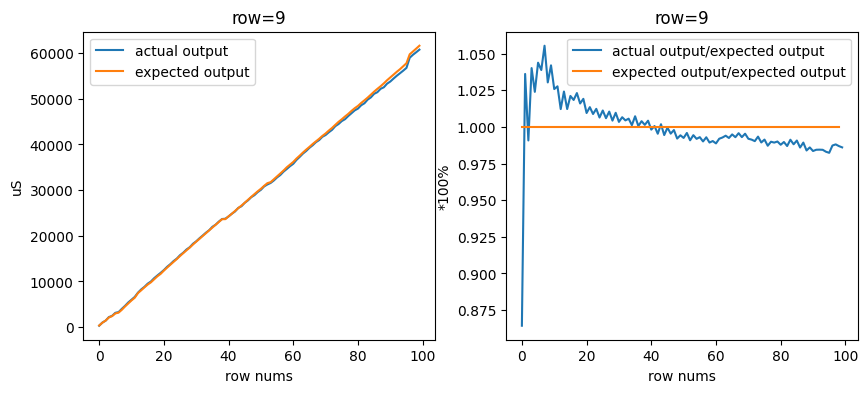

In [58]:
startpos,endpos = 0,100
for num in range(10):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond[startpos:endpos,num].flatten()*mult_fit[num],label = "actual output")
    plt.plot(expected_cond[startpos:endpos,num].flatten(),label = "expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    plt.plot(real_cond[startpos:endpos,num].flatten()/expected_cond[startpos:endpos,num].flatten()*mult_fit[num],label = "actual output/expected output")
    plt.plot(np.ones(endpos-startpos-1),label = "expected output/expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

### 3.3 随机输入并行读

In [62]:
import random
chip.compensation.initop(root_path)
expected_cond = np.zeros((256,256))
real_cond = np.zeros((256,256))
start_pos,end_pos = 0,100
row_index = [i for i in range(256)]
chip.setting.tia_map = None#[i for i in range(16)] *2
all_num = 200
for i in range(all_num):
    random_number = random.randint(20, 100)
    col_index = random.sample(range(1,101), random_number)

    _,cond,r = chip.read4(crossbar=np.ones((256,256)),row_index=row_index,col_index=col_index,read_voltage=0.1,tg=5,gain=3,sub_base=True,from_row=False,split_type=4,row_type=0,col_type=0)
    cond = chip.compensation.compensation_forward(col_index,r,from_row=False,return_type=0)
    pos = np.ix_(row_index,col_index)
    expected_cond[i,:]=np.sum(c_expected_from_col[pos],axis=1).flatten()
    real_cond[i,:] = cond[row_index]

In [63]:
def compensation_value_from_col(x,mult,row):
    """
        计算补偿
    """
    rows = len(x)
    return real_cond[:rows,row]/expected_cond[:rows,row]*mult

cnt = all_num
mult_fit = np.zeros(256)
for i in range(256):
    params, covariance = curve_fit(lambda x,value:compensation_value_from_col(x,value,i),
                                   [i for i in range(cnt)], np.ones(cnt), p0=[0.5],bounds=([0], [2]))
    mult_fit[i] = params[0]

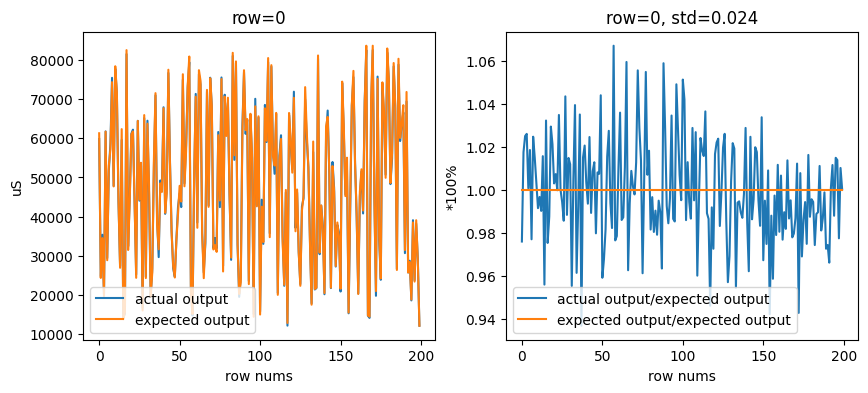

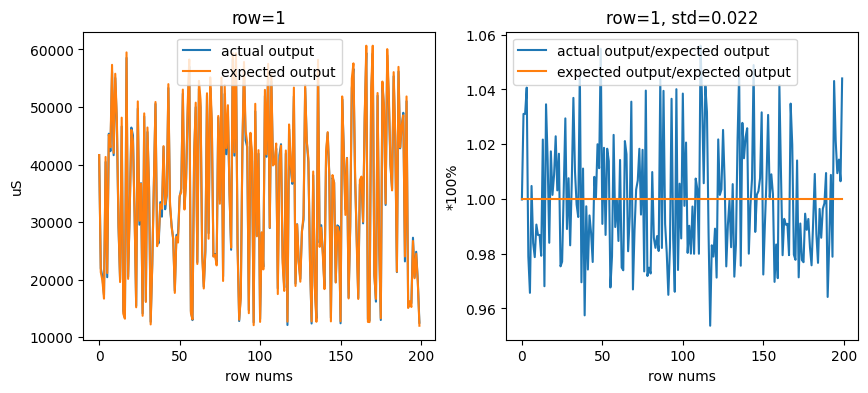

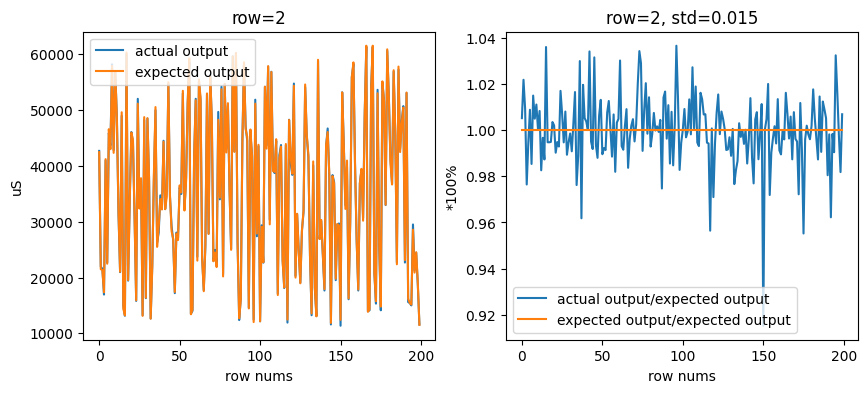

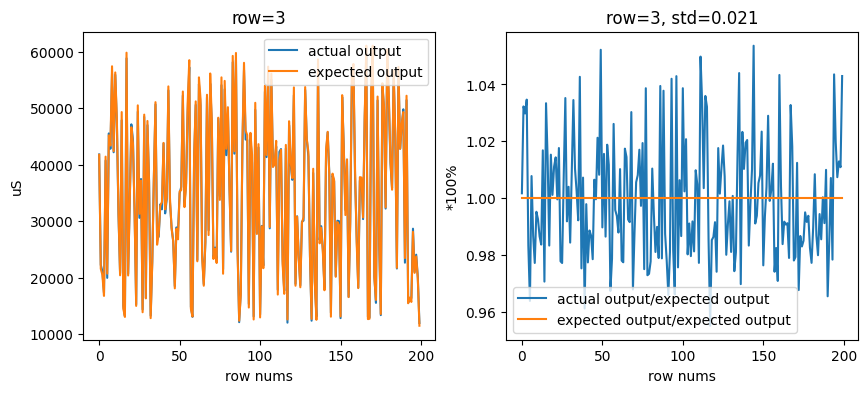

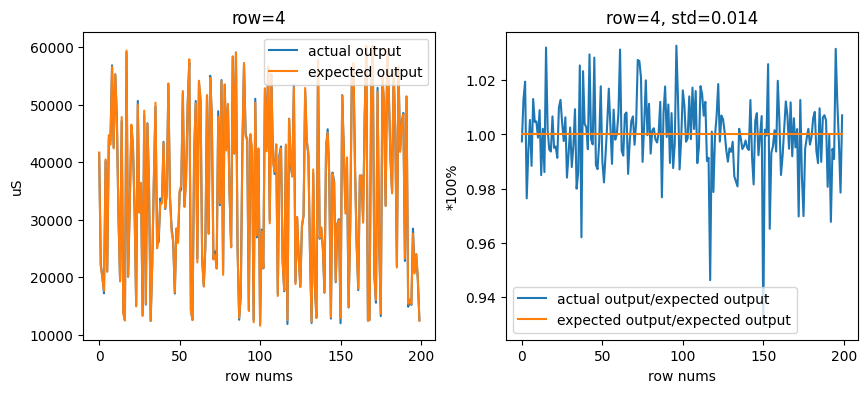

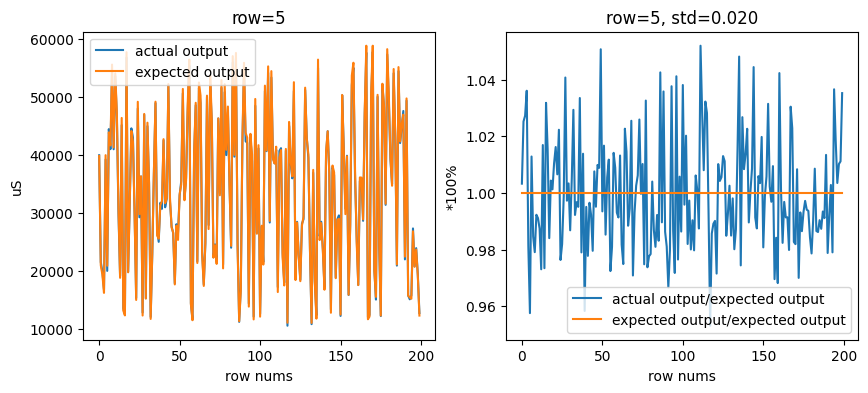

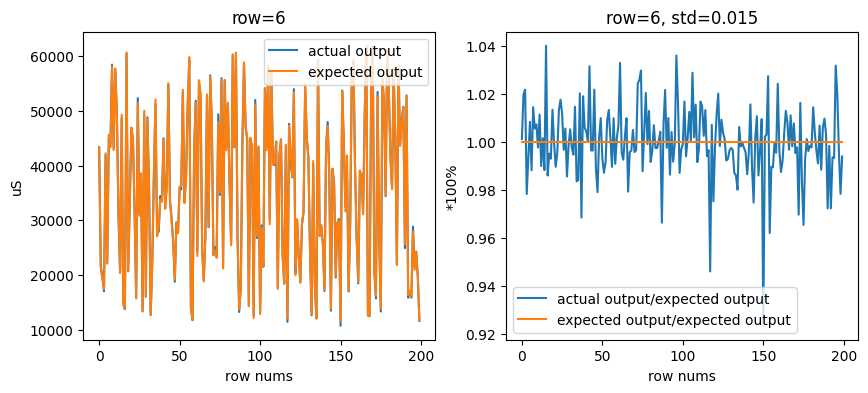

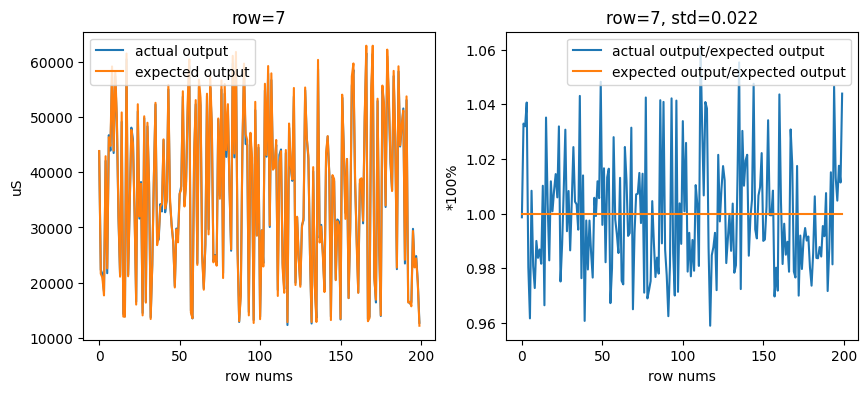

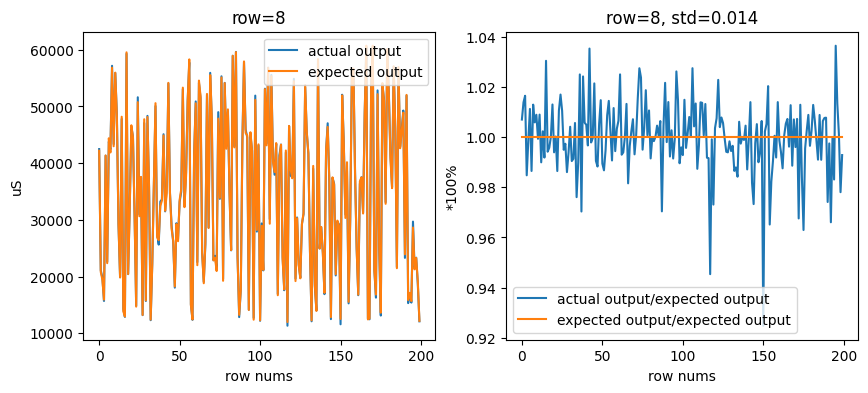

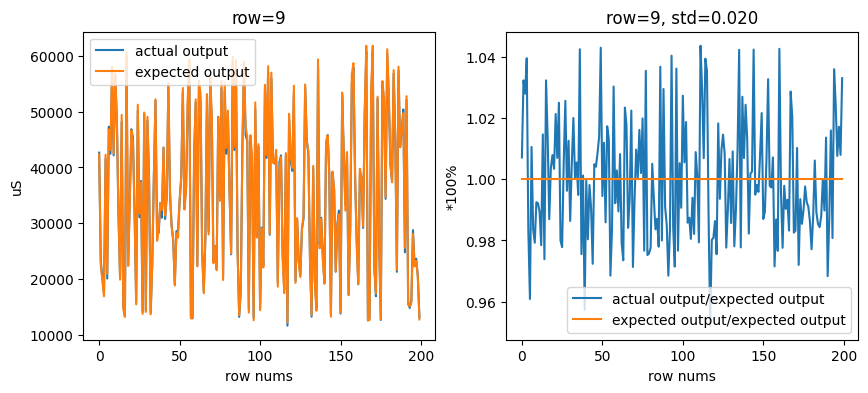

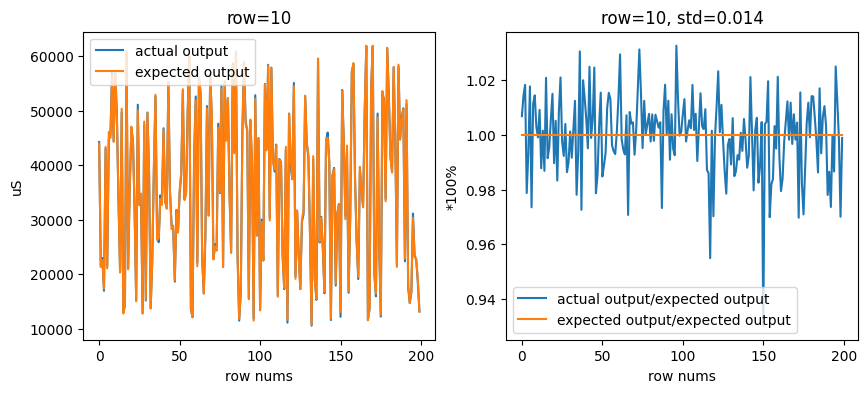

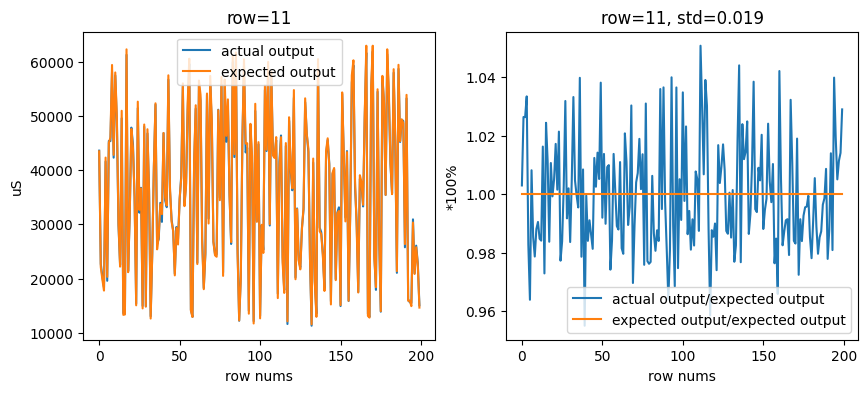

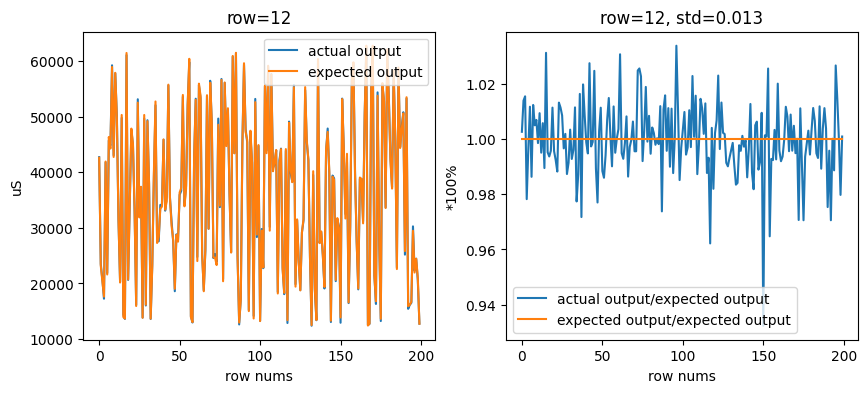

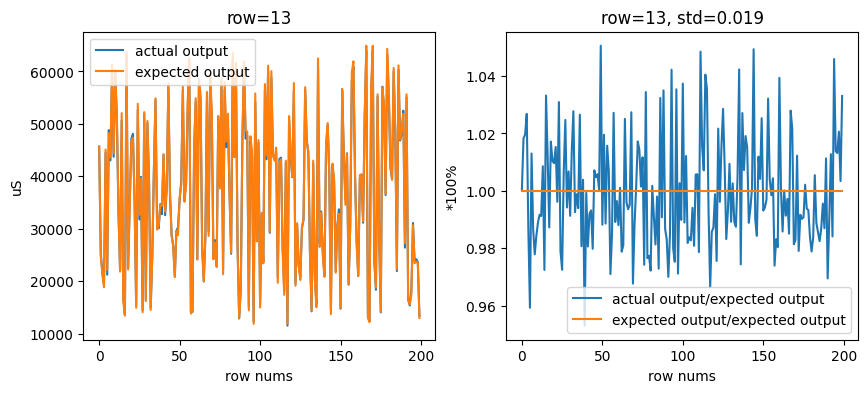

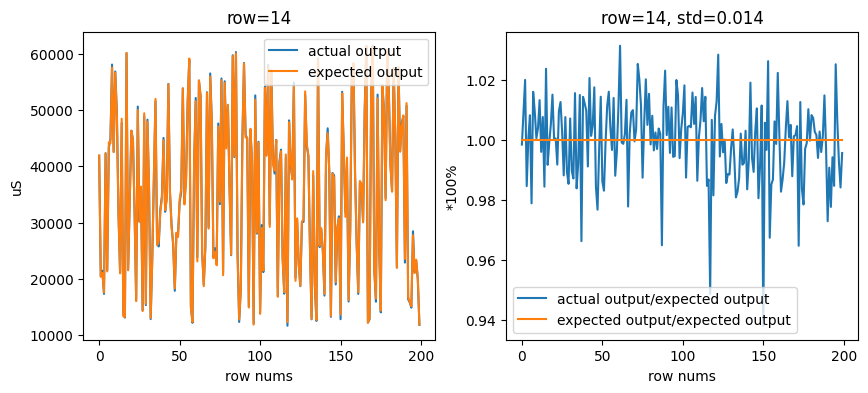

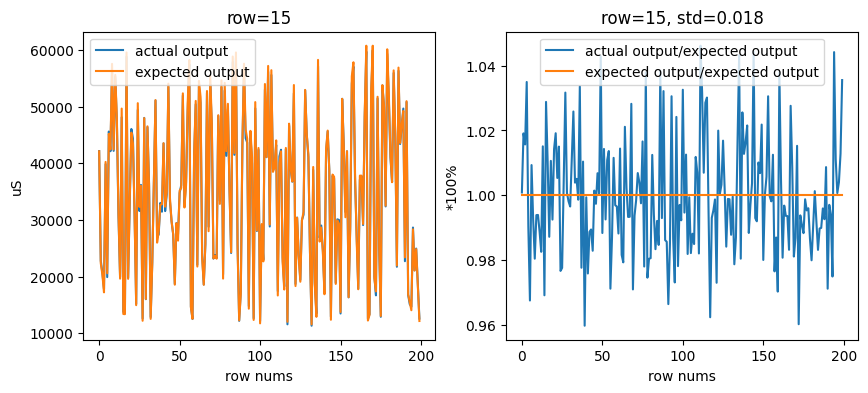

In [64]:

for num in range(16):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(real_cond[:all_num,num].flatten()*mult_fit[num],label = "actual output")
    plt.plot(expected_cond[:all_num,num].flatten(),label = "expected output")
    plt.title(f"row={row_index[num]}")
    plt.ylabel("uS")
    plt.xlabel("row nums")
    plt.legend()
    # plt.show()
    plt.subplot(1,2,2)
    res = real_cond[:all_num,num].flatten()/expected_cond[:all_num,num].flatten()*mult_fit[num]
    plt.plot(res,label = "actual output/expected output")
    var = np.var(res)
    std = np.sqrt(var)
    plt.plot(np.ones(all_num),label = "expected output/expected output")
    plt.title(f"row={row_index[num]}, std={float(std):.3f}")
    plt.ylabel("*100%")
    plt.xlabel("row nums")
    plt.legend()
    plt.show()

# 4. 测试ADC噪声

In [ ]:
crossbar = np.ones((256,256))
v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=1,sub_base=False,from_row=True,split_type=0,row_type=0,col_type=0)
plot_cond(c,vmax=1000)
plot_cond(v*1000,vmax=120)

In [ ]:
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=500,adc_last_gap=10)

In [ ]:
crossbar = np.zeros((256,256))
pos = np.ix_([i for i in range(200,220)],[i for i in range(32)]+[i for i in range(128,160)]+[i for i in range(224,256)])
crossbar[pos]=1

for samples in [1,2,4,8,16,32]:
    for gain in [3,1,2,0]:
        ans_v = []
        ans_c = []
        chip.adc.set_sample_times(adc_sample_times=samples)
        for i in range(100):
            v,c,r = chip.read4(crossbar=crossbar,row_index=None,col_index=None,read_voltage=0.1,tg=5,gain=gain,sub_base=True,from_row=True,split_type=0,row_type=0,col_type=0)
            ans_v.append(v[pos])
            ans_c.append(c[pos])
        np.save(f"../data/adc/pcb203/5samples{samples}_v_gain={gain}_v=0_1.npy",np.array(ans_v))
        np.save(f"../data/adc/pcb203/5samples{samples}_c_gain={gain}_v=0_1.npy",np.array(ans_c))

In [ ]:
def adc_plot(mean_data,std_data,mean_max,std_max,gain,samples,label):
    plt.figure(figsize=(16,4))
    # 均值
    plt.subplot(1,3,1)
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=mean_max)
    im = plt.imshow(mean_data, cmap=cmap,norm=norm)
    cbar = plt.colorbar(im)
    cbar.set_label(label)
    plt.title(f"gian={gain}-samples={samples}-mean_{label}")
    # 标准差
    plt.subplot(1,3,2)
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=std_max)
    im = plt.imshow(std_data, cmap=cmap,norm=norm)
    cbar = plt.colorbar(im)
    cbar.set_label(label)
    plt.title(f"gian={gain}-samples={samples}-std_{label}-{np.mean(std_data):.2f}")
    # 百分比
    plt.subplot(1,3,3)
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=5)
    im = plt.imshow(std_data/mean_data*100, cmap=cmap,norm=norm)
    cbar = plt.colorbar(im)
    cbar.set_label("100%")
    plt.title(f"gian={gain}-percent")

### gain3

In [ ]:
gain = 1


for samples in [1,2,4,8,16,32]:
    for gain in [0]:
        ans_v = np.load(f"../data/adc/pcb203/samples{samples}_v_gain={gain}_v=0_1.npy")
        ans_c = np.load(f"../data/adc/pcb203/samples{samples}_c_gain={gain}_v=0_1.npy")
        # matrices = np.array(ans_v)
        # mean_matrix = np.mean(matrices, axis=0)
        # var_matrix = np.var(matrices, axis=0)
        # std_matrix = np.sqrt(var_matrix)
        # adc_plot(mean_data=mean_matrix*1000,std_data=std_matrix*1000,mean_max=20,std_max=0.2,gain=gain,samples=samples,label="mv")


        matrices = np.array(ans_c)
        mean_matrix = np.mean(matrices, axis=0)
        var_matrix = np.var(matrices, axis=0)
        std_matrix = np.sqrt(var_matrix)
        adc_plot(mean_data=mean_matrix,std_data=std_matrix,mean_max=1200,std_max=10,gain=gain,samples=samples,label="us")


### gain1

In [ ]:
gain = 1
for samples in [1,2,4,8,16,32]:
    ans_v = np.load(f"../data/adc/pcb203/samples{samples}_v_gain={gain}_v=0_1.npy")
    ans_c = np.load(f"../data/adc/pcb203/samples{samples}_c_gain={gain}_v=0_1.npy")

    matrices = np.array(ans_v)
    mean_matrix = np.mean(matrices, axis=0)
    var_matrix = np.var(matrices, axis=0)
    std_matrix = np.sqrt(var_matrix)
    adc_plot(mean_data=mean_matrix*1000,std_data=std_matrix*1000,mean_max=120,std_max=1,gain=gain,samples=samples,label="mv")

    matrices = np.array(ans_c)
    mean_matrix = np.mean(matrices, axis=0)
    var_matrix = np.var(matrices, axis=0)
    std_matrix = np.sqrt(var_matrix)
    adc_plot(mean_data=mean_matrix,std_data=std_matrix,mean_max=1200,std_max=10,gain=gain,samples=samples,label="us")


### gain2

In [ ]:
gain = 2
ans_v = np.load(f"../data/adc/pcb203/samples{samples}_v_gain={gain}_v=0_1.npy")
ans_c = np.load(f"../data/adc/pcb203/samples{samples}_c_gain={gain}_v=0_1.npy")
matrices = np.array(ans_v)

mean_matrix = np.mean(matrices, axis=0)
var_matrix = np.var(matrices, axis=0)
std_matrix = np.sqrt(var_matrix)
adc_plot(mean_data=mean_matrix*1000,std_data=std_matrix*1000,mean_max=1250,std_max=10,gain=gain,samples=samples,label="mv")

matrices = np.array(ans_c)

mean_matrix = np.mean(matrices, axis=0)
var_matrix = np.var(matrices, axis=0)
std_matrix = np.sqrt(var_matrix)
adc_plot(mean_data=mean_matrix,std_data=std_matrix,mean_max=1200,std_max=10,gain=gain,samples=samples,label="us")


### gain0

In [ ]:
gain = 0
ans_v = np.load(f"../data/adc/pcb203/samples{samples}_v_gain={gain}_v=0_1.npy")
ans_c = np.load(f"../data/adc/pcb203/samples{samples}_c_gain={gain}_v=0_1.npy")
matrices = np.array(ans_v)

mean_matrix = np.mean(matrices, axis=0)
var_matrix = np.var(matrices, axis=0)
std_matrix = np.sqrt(var_matrix)
adc_plot(mean_data=mean_matrix*1000,std_data=std_matrix*1000,mean_max=1250,std_max=10,gain=gain,samples=samples,label="mv")

matrices = np.array(ans_c)

mean_matrix = np.mean(matrices, axis=0)
var_matrix = np.var(matrices, axis=0)
std_matrix = np.sqrt(var_matrix)
adc_plot(mean_data=mean_matrix,std_data=std_matrix,mean_max=200,std_max=10,gain=gain,samples=samples,label="us")


# 5. 测试ADC读

In [ ]:
samples = 32
gain = 1
ans_v = np.load(f"../data/adc/pcb203/2samples{samples}_v_gain={gain}_v=0_1.npy")
ans_c = np.load(f"../data/adc/pcb203/2samples{samples}_c_gain={gain}_v=0_1.npy")

row = 0
col = 5
c = ans_c[:,row,col]
plt.plot(c)
plt.ylabel("uS")
plt.xlabel("read times")
plt.title(f"samples = {samples},gain = {gain},row={row},col={col}")
plt.show()

In [ ]:
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=100,adc_last_gap=10)
chip.adc.set_sample_times(adc_sample_times=32)

In [ ]:
chip.ps.receive_packet(1024)

In [ ]:
print(chip.setting.TIA_index_map(100,col=True))

In [ ]:
crossbar = np.zeros((256,256))
ans = []
ans1 = []
row =11
col =100
adc_first_gap = 200
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=adc_first_gap,adc_last_gap=30)
chip.adc.set_sample_times(adc_sample_times=32)

crossbar[0:20,100:200]=1
sleep_time = 5
gain = 0
for k in range(5):
    # time.sleep(sleep_time)
    for i in range(100):
        v,cond,_ = chip.read4(crossbar=crossbar,row_index=[row],col_index=[col],read_voltage=0.1,tg=5,gain=gain,sub_base=True,from_row=True,split_type=6,row_type=0,col_type=0)
        ans.append(cond[row,col])
        ans1.append(v[row,col])

plt.plot(ans[:])
plt.ylabel("uS")
plt.xlabel("read times")
plt.title(f"row={row},col={col},gain = {gain},sleep time = {sleep_time}s,adc_first_gap={adc_first_gap*10}ns")
plt.show()

In [ ]:
plt.plot(ans[1:])
plt.ylabel("uS")
plt.xlabel("read times")
plt.title(f"row={row},col={col},gain = {gain},sleep time = {sleep_time}s,adc_first_gap={adc_first_gap*10}ns")
plt.show()